In [13]:
import numpy as np
import time
from os import path
import os
import sys
from pyuvdata import UVData
import pyuv_helper as ph
sys.path.insert(0,path.expanduser("~/albatros_analysis"))
from scripts.orbcomm import sat_utils as su
from scripts.orbcomm import figures as fgs_o
from src.utils import orbcomm_utils as outils
import psutil
import matplotlib.pyplot as plt
import json

In [14]:
def print_mem(process, label):
    mem = process.memory_info().rss / (1024**2)
    print(f"{label}: {mem:.2f} MB")

def load_pyuv(disk_path, **kwargs):
    uv = UVData()
    p = psutil.Process(os.getpid())
    t0 = time.time()

    mem1 = p.memory_info().rss / (1024**2)
    uv.read_uvh5(disk_path, **kwargs)
    mem2 = p.memory_info().rss / (1024**2)

    t1 = time.time()
    print(f"READ TIME: {t1 - t0:.3f} s")
    print(f"MEMORY: {mem2 - mem1:.4f} MB")
    print(f'DATA ARR SIZE: {uv.data_array.nbytes/(1024**2)} MB')
    print(f'DATA SHAPE: {uv.data_array.shape}')
    return uv

In [15]:
config_path = '/home/thomasb/albatros_analysis/scripts/xcorr/config/config_bright_test.json'

#disk_path = '/scratch/thomasb/xcorr_all_ant_1bit_1753132830_1753133200_512_64_344_260_280.pyuv'
disk_path = '/scratch/thomasb/xcorr_all_ant_1bit_1753216650_1753217000_512_64_325_1834_1852.uvh5'

with open(config_path, "r") as f:
    config = json.load(f)
ant_names, ant_coords, dir_parents, spec_offsets = [], [], [], []
# Call get_starting_index for all antennas except reference
for i, (ant, details) in enumerate(config["antennas"].items()):
    dir_parents.append(details["path"])
    spec_offsets.append(details["clock_offset"])
    ant_names.append(details["name"])
    ant_coords.append(details["coordinates"])

ant_numbers = np.array([int(name.split()[1]) for name in ant_names])
init_t = config["correlation"]["start_timestamp"]
end_t = config["correlation"]["end_timestamp"]
chanstart = config["frequency"]["start_channel"]
chanend = config["frequency"]["end_channel"]
osamp = config["correlation"]["osamp"]
pfb_size = config["correlation"]["pfb_size"]
new_acclen = config["correlation"]["new_acclen"]

new_chunk_len = (new_acclen*4096*osamp)/250e6

In [27]:
uv_disk = UVData()
uv_disk.read(disk_path)
print(uv_disk)

The uvw_array does not match the expected values given the antenna positions. The largest discrepancy is 15162.725505130295 meters. This is a fairly common situation but might indicate an error in the antenna positions, the uvws or the phasing.
Fixing auto-correlations to be be real-only, after some imaginary values were detected in data_array. Largest imaginary component was 42.917842864990234, largest imaginary/real ratio was 659693.882616829.


In [29]:
print(uv_disk.uvw_array)

[[ 0.00000000e+00  0.00000000e+00  0.00000000e+00]
 [ 1.74207630e+02  4.42657662e+00 -4.58660816e+00]
 [-5.18559216e+03 -3.19565770e+03 -1.71217329e+02]
 ...
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00]
 [-4.74112055e+02  3.60470420e+03  3.83670023e+02]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00]]


In [26]:
uv_disk.get_enu_data_ants()

(array([[-1.07492892e-09, -2.30055984e-09, -3.35992807e-09],
        [ 1.74132740e+02,  5.80150876e+00, -5.74989682e+00],
        [-5.14233714e+03, -3.24071905e+03,  4.31298397e+02],
        [ 2.04475344e+03,  1.29681194e+02, -1.55521764e+02],
        [-6.42145901e+02, -2.14079109e+03,  2.51654304e+02],
        [ 1.48457982e+03, -6.33169761e+02, -4.01000388e+01],
        [ 9.62242977e+02,  2.97412553e+03, -3.23758614e+02]]),
 array([1, 2, 4, 5, 6, 7, 8]))

In [19]:
uv_disk.telescope.get_enu_antpos()

array([[-1.07492892e-09, -2.30055984e-09, -3.35992807e-09],
       [ 1.74132740e+02,  5.80150876e+00, -5.74989682e+00],
       [-5.14233714e+03, -3.24071905e+03,  4.31298397e+02],
       [ 2.04475344e+03,  1.29681194e+02, -1.55521764e+02],
       [-6.42145901e+02, -2.14079109e+03,  2.51654304e+02],
       [ 1.48457982e+03, -6.33169761e+02, -4.01000388e+01],
       [ 9.62242977e+02,  2.97412553e+03, -3.23758614e+02]])

In [5]:
#check the metadata
uv_disk = UVData()
uv_disk.read_uvh5(disk_path, read_data=False)
uv_disk.check(check_extra = True)

The uvw_array does not match the expected values given the antenna positions. The largest discrepancy is 15162.725505130295 meters. This is a fairly common situation but might indicate an error in the antenna positions, the uvws or the phasing.
The uvw_array does not match the expected values given the antenna positions. The largest discrepancy is 15162.725505130295 meters. This is a fairly common situation but might indicate an error in the antenna positions, the uvws or the phasing.


True

In [6]:
#overall read time
uv_all = load_pyuv(disk_path)

The uvw_array does not match the expected values given the antenna positions. The largest discrepancy is 15162.725505130295 meters. This is a fairly common situation but might indicate an error in the antenna positions, the uvws or the phasing.
Fixing auto-correlations to be be real-only, after some imaginary values were detected in data_array. Largest imaginary component was 42.917842864990234, largest imaginary/real ratio was 1193408.004670663.


READ TIME: 14.224 s
MEMORY: 1695.1992 MB
DATA ARR SIZE: 1279.6875 MB
DATA SHAPE: (18200, 1152, 4)


In [17]:
#fixed frequencies
uv_chans = load_pyuv(disk_path, freq_chans = np.arange(200, 800))

The uvw_array does not match the expected values given the antenna positions. The largest discrepancy is 15162.725505130295 meters. This is a fairly common situation but might indicate an error in the antenna positions, the uvws or the phasing.
Fixing auto-correlations to be be real-only, after some imaginary values were detected in data_array. Largest imaginary component was 27.07270050048828, largest imaginary/real ratio was 1193408.004670663.


READ TIME: 37.528 s
MEMORY: 872.1992 MB
DATA ARR SIZE: 666.50390625 MB
DATA SHAPE: (18200, 600, 4)


In [18]:
uv_blts = load_pyuv(disk_path, blt_inds = np.arange(1000, 6000))

READ TIME: 1.851 s
MEMORY: 421.1289 MB
DATA ARR SIZE: 351.5625 MB
DATA SHAPE: (5000, 1152, 4)


The uvw_array does not match the expected values given the antenna positions. The largest discrepancy is 15161.757563894684 meters. This is a fairly common situation but might indicate an error in the antenna positions, the uvws or the phasing.
Fixing auto-correlations to be be real-only, after some imaginary values were detected in data_array. Largest imaginary component was 42.917842864990234, largest imaginary/real ratio was 493327.9195916048.


In [19]:
uv_bltpol = load_pyuv(disk_path, bls = [(1,8)])

READ TIME: 2.590 s
MEMORY: 85.5859 MB
DATA ARR SIZE: 45.703125 MB
DATA SHAPE: (650, 1152, 4)


The uvw_array does not match the expected values given the antenna positions. The largest discrepancy is 2949.9434386074836 meters. This is a fairly common situation but might indicate an error in the antenna positions, the uvws or the phasing.


In [20]:
load_pyuv(disk_path, bls = [(1,8, 'xx')])

READ TIME: 2.463 s
MEMORY: 16.9219 MB
DATA ARR SIZE: 11.42578125 MB
DATA SHAPE: (650, 1152, 1)


The uvw_array does not match the expected values given the antenna positions. The largest discrepancy is 2949.9434386074836 meters. This is a fairly common situation but might indicate an error in the antenna positions, the uvws or the phasing.


In [14]:
data_all = uv_all.data_array
antnums = uv_all.telescope.antenna_numbers
ant1, ant2 = 1, 2
ant1_idx, ant2_idx = np.where(antnums == ant1)[0][0], np.where(antnums == ant2)[0][0]
coords1, coords2 = ant_coords[ant1_idx], ant_coords[ant2_idx]
name1, name2 = ant_names[ant1_idx], ant_names[ant2_idx]
bl_slice = uv_all.antpair2ind(ant1, ant2)
bl_12_data = data_all[bl_slice, :, 0]
bl_12_angle = np.angle(bl_12_data)

print(ant1, ant2)
print(ant1_idx, ant2_idx)
print(bl_12_data.shape)

1 2
0 1
(650, 1152)


170
1836.65625
catalog #57166 epoch 2025-07-22 18:35:47 UTC
one delay prediction: 0.08407425880432129
time taken pred 0.08564209938049316
MAX PHASE DIFFERENCE: 1.1727323641310363


<function matplotlib.pyplot.tight_layout(*, pad: 'float' = 1.08, h_pad: 'float | None' = None, w_pad: 'float | None' = None, rect: 'tuple[float, float, float, float] | None' = None) -> 'None'>

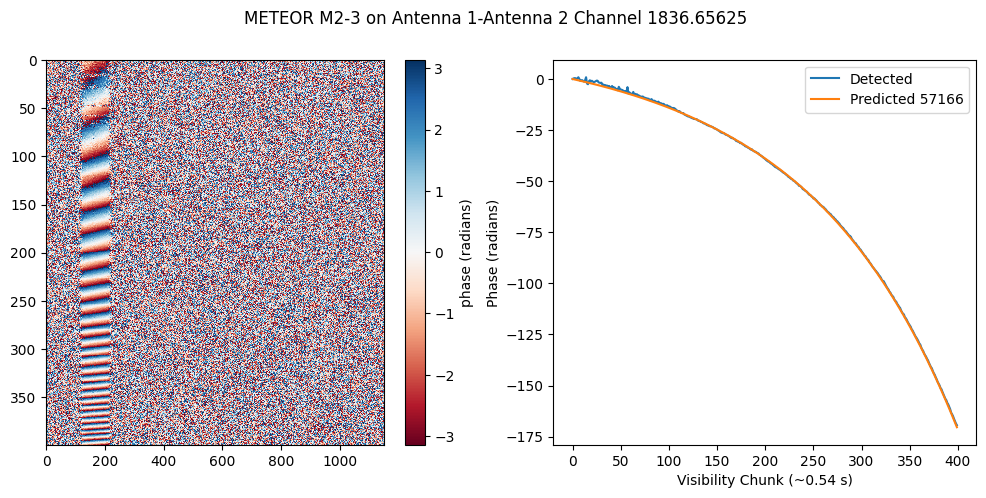

In [8]:
chan_new = 170
chan_old = 1834 + (chan_new/osamp)
print(chan_new)
print(chan_old)

bl_12_angle = bl_12_angle[:400, :]

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle(f'METEOR M2-3 on {name1}-{name2} Channel {chan_old}')

im = ax[0].imshow(bl_12_angle, aspect='auto', cmap='RdBu', interpolation='none')
#ax[0].set_xlabel("channel idx (~60 kHz interval)")
#ax[0].set_ylabel("chunk number (~0.5 s interval)")
cbar = fig.colorbar(im, ax=ax[0], orientation='vertical')
cbar.set_label("phase (radians)")


phase = np.unwrap(bl_12_angle[:, chan_new] - bl_12_angle[0, chan_new])
satID = 57166
pred_phase = outils.pred(coords1, 
                         coords2, 
                         init_t, 
                         end_t, 
                         chan_old, 
                         int(satID), 
                         v_acclen=new_acclen, 
                         T_SPECTRA = (4096*osamp)/250e6)[:len(phase)]

ax[1].plot(phase, label='Detected')
ax[1].plot(pred_phase, label=f'Predicted {satID}')
ax[1].set_xlabel(f"Visibility Chunk (~{np.round(new_chunk_len, decimals=2)} s)")
ax[1].set_ylabel("Phase (radians)")


print('MAX PHASE DIFFERENCE:', np.max(np.diff(np.abs(pred_phase))))
ax[1].legend()
plt.tight_layout

<function matplotlib.pyplot.tight_layout(*, pad: 'float' = 1.08, h_pad: 'float | None' = None, w_pad: 'float | None' = None, rect: 'tuple[float, float, float, float] | None' = None) -> 'None'>

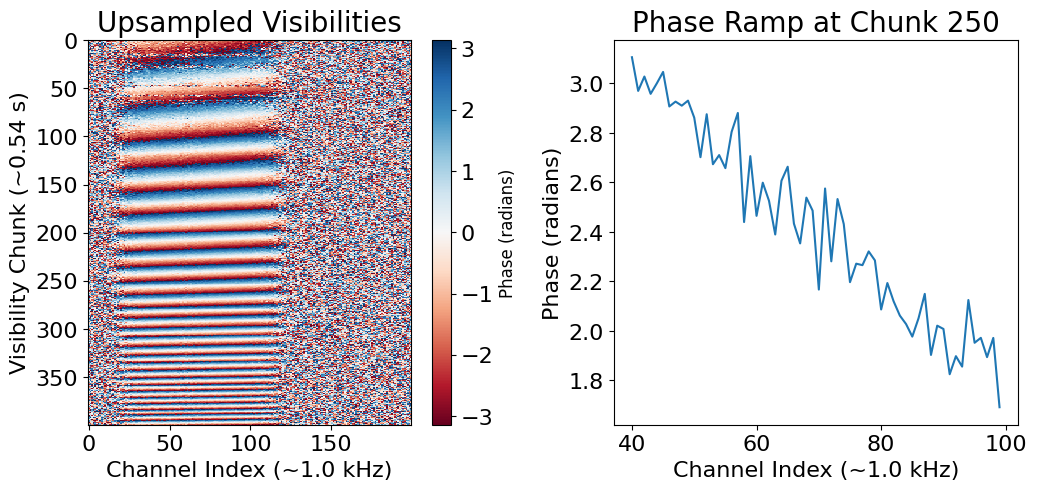

In [33]:
chan_new_start = 40
chan_new_end = 100
chan_old_start = 1834 + (chan_new_start/osamp)
chan_old_end = 1834 + (chan_new_end/osamp)

fixed_chunk = 250

bl_12_angle_cut = bl_12_angle[:400, 100:300]

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
#fig.suptitle(f'METEOR M2-3 on {name1}-{name2} Channel {chan_old}')

plt.rcParams.update({
            "font.size": 16,
            "axes.labelsize": 16,
            "axes.titlesize": 20,
            "xtick.labelsize": 16,
            "ytick.labelsize": 16,
            "figure.titlesize": 22
        })

plt.subplots_adjust(wspace=0.3)

im = ax[0].imshow(bl_12_angle_cut, aspect='auto', cmap='RdBu', interpolation='none')
#ax[0].set_xlabel("channel idx (~60 kHz interval)")
#ax[0].set_ylabel("chunk number (~0.5 s interval)")
ax[0].set_title('Upsampled Visibilities')
ax[0].set_xlabel(f"Channel Index (~{np.round((250e6/(4096*osamp*1000)), decimals=0)} kHz)")
ax[0].set_ylabel(f"Visibility Chunk (~{np.round(new_chunk_len, decimals=2)} s)")
cbar = fig.colorbar(im, ax=ax[0], orientation='vertical')
cbar.set_label("Phase (radians)", fontsize =12)

phase_ramp = bl_12_angle_cut[fixed_chunk, chan_new_start : chan_new_end]

ax[1].plot(np.arange(chan_new_start, chan_new_end), phase_ramp)
ax[1].set_title(f'Phase Ramp at Chunk {fixed_chunk}')
ax[1].set_xlabel(f"Channel Index (~{np.round((250e6/(4096*osamp*1000)), decimals=0)} kHz)")
ax[1].set_ylabel("Phase (radians)")

plt.tight_layout

In [36]:
bl_12_angle_bf = bl_12_angle[:400, :300]

for i in range(300):
    k = 1834 + (i/osamp)
    bf = outils.pred(coords1, 
                     coords2, 
                     init_t, 
                     end_t, 
                     k, 
                     int(satID), 
                     v_acclen=new_acclen, 
                     T_SPECTRA = (4096*osamp)/250e6)[:400]

    # Convert both angles to phasors and multiply
    combined = np.exp(1j * bl_12_angle_bf[:, i]) * np.exp(1j * bf)

    # Store the wrapped angle
    bl_12_angle_bf[:, i] = np.angle(combined)


catalog #57166 epoch 2025-07-22 18:35:47 UTC
one delay prediction: 0.08043408393859863
time taken pred 0.08207035064697266
catalog #57166 epoch 2025-07-22 18:35:47 UTC
one delay prediction: 0.076873779296875
time taken pred 0.07709622383117676
catalog #57166 epoch 2025-07-22 18:35:47 UTC
one delay prediction: 0.076904296875
time taken pred 0.07725214958190918
catalog #57166 epoch 2025-07-22 18:35:47 UTC
one delay prediction: 0.07718610763549805
time taken pred 0.07737350463867188
catalog #57166 epoch 2025-07-22 18:35:47 UTC
one delay prediction: 0.07716846466064453
time taken pred 0.07738041877746582
catalog #57166 epoch 2025-07-22 18:35:47 UTC
one delay prediction: 0.0768899917602539
time taken pred 0.07720661163330078
catalog #57166 epoch 2025-07-22 18:35:47 UTC
one delay prediction: 0.07654356956481934
time taken pred 0.07672429084777832
catalog #57166 epoch 2025-07-22 18:35:47 UTC
one delay prediction: 0.07718110084533691
time taken pred 0.07736897468566895
catalog #57166 epoch 202

<function matplotlib.pyplot.tight_layout(*, pad: 'float' = 1.08, h_pad: 'float | None' = None, w_pad: 'float | None' = None, rect: 'tuple[float, float, float, float] | None' = None) -> 'None'>

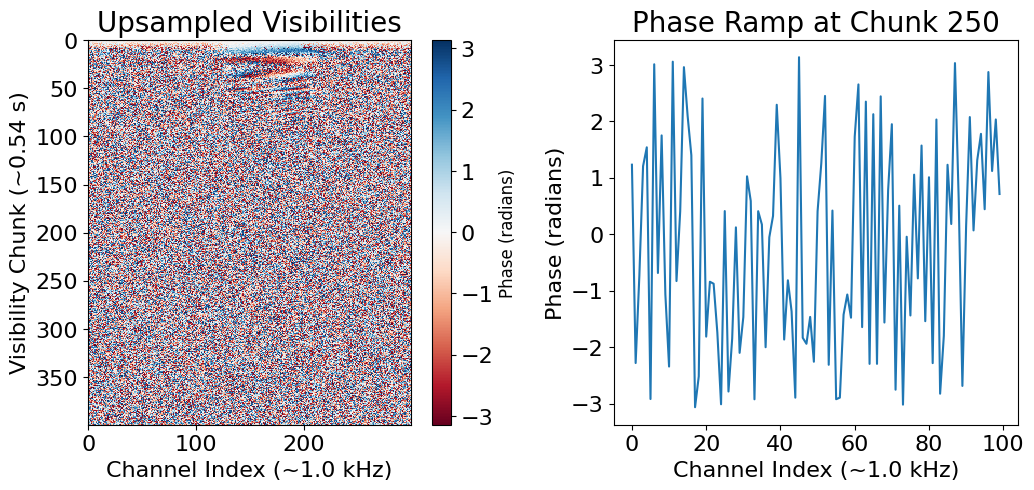

In [37]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
#fig.suptitle(f'METEOR M2-3 on {name1}-{name2} Channel {chan_old}')

cidx_st = 0
cidx_end = 0

plt.rcParams.update({
            "font.size": 16,
            "axes.labelsize": 16,
            "axes.titlesize": 20,
            "xtick.labelsize": 16,
            "ytick.labelsize": 16,
            "figure.titlesize": 22
        })

plt.subplots_adjust(wspace=0.3)

im = ax[0].imshow(bl_12_angle_bf, aspect='auto', cmap='RdBu', interpolation='none')
#ax[0].set_xlabel("channel idx (~60 kHz interval)")
#ax[0].set_ylabel("chunk number (~0.5 s interval)")
ax[0].set_title('Upsampled Visibilities')
ax[0].set_xlabel(f"Channel Index (~{np.round((250e6/(4096*osamp*1000)), decimals=0)} kHz)")
ax[0].set_ylabel(f"Visibility Chunk (~{np.round(new_chunk_len, decimals=2)} s)")
cbar = fig.colorbar(im, ax=ax[0], orientation='vertical')
cbar.set_label("Phase (radians)", fontsize =12)

phase_ramp = bl_12_angle_cut[fixed_chunk, 100 : 200]

ax[1].plot(phase_ramp)
ax[1].set_title(f'Phase Ramp at Chunk {fixed_chunk}')
ax[1].set_xlabel(f"Channel Index (~{np.round((250e6/(4096*osamp*1000)), decimals=0)} kHz)")
ax[1].set_ylabel("Phase (radians)")

plt.tight_layout